# 7주차 : LSTM 모델 완성 및 벤치마크 모델과의 비교

In [18]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import random

In [19]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

데이터 불러오기

In [20]:
file_path = './processed_sequences/train_data_seq_30d.csv' 
df = pd.read_csv(file_path)

print(f"데이터 전체 형태 {df.shape}")


데이터 전체 형태 (208080, 35)


Train / Test 데이터 분할  
이전 전처리 과정에서 만들어둔 'dataset_type' 컬럼을 활용

In [4]:
train_df = df[df['dataset_type'] == 'Train']
test_df = df[df['dataset_type'] == 'Test']


Feature 와 target 분리  
t-로 시작하는 컬럼들을 찾아 입력피처로 사용

In [5]:
seq_length = 30
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]

거른 입력 피처들의 열 이름을 통해 값만 불러오기

In [6]:
X_train = train_df[feature_cols].values
y_train = train_df['target'].values

X_test = test_df[feature_cols].values
y_test = test_df['target'].values


In [7]:
print(pd.DataFrame(X_train).head(3))
print(pd.DataFrame(X_train).shape)
print(pd.DataFrame(y_train).shape)
print(pd.DataFrame(X_test).shape)
print(pd.DataFrame(y_test).shape)

         0         1         2         3         4         5         6   \
0  0.179889 -0.022025 -0.022025  1.934757  1.055462 -0.916125  1.939273   
1 -0.022025 -0.022025  1.934757  1.055462 -0.916125  1.939273 -0.507128   
2 -0.022025  1.934757  1.055462 -0.916125  1.939273 -0.507128 -0.022025   

         7         8         9   ...        20        21        22        23  \
0 -0.507128 -0.022025 -0.022025  ...  0.087410 -0.738527 -0.022025 -0.022025   
1 -0.022025 -0.022025 -1.227534  ... -0.738527 -0.022025 -0.022025 -0.422895   
2 -0.022025 -1.227534 -0.453952  ... -0.022025 -0.022025 -0.422895 -1.161767   

         24        25        26        27        28        29  
0 -0.422895 -1.161767  0.238271  0.133356  0.671674 -0.022025  
1 -1.161767  0.238271  0.133356  0.671674 -0.022025 -0.022025  
2  0.238271  0.133356  0.671674 -0.022025 -0.022025 -1.307094  

[3 rows x 30 columns]
(153360, 30)
(153360, 1)
(54720, 30)
(54720, 1)


PyTorch Tensor로 변환 및 차원 추가  
PyTorch LSTM은 항상 3차원 입력을 받는다고 하니 이걸 최대한 구현: (Batch_size, Sequence_length, Input_size)  
논문과 동일하게 하나의 피처(수익률) 사용하므로 Input_size = 1  

In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1) # 마지막 차원 추가
y_train_tensor = torch.tensor(y_train, dtype=torch.long) # 분류를 위한 정수형 타겟

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("\n[데이터 텐서 변환 완료]")
print(f"X_train 형태: {X_train_tensor.shape} -> (배치 크기, 시퀀스 길이={seq_length}, 입력 변수 개수=1)")
print(f"y_train 형태: {y_train_tensor.shape}")

batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # 테스트 시에는 셔플 생략


[데이터 텐서 변환 완료]
X_train 형태: torch.Size([153360, 30, 1]) -> (배치 크기, 시퀀스 길이=30, 입력 변수 개수=1)
y_train 형태: torch.Size([153360])


## LSTM 셀 만들기

LSTM의 CELL 정의  
- 이니셜라이즈
- 순전파 기능

**이니셜라이즈**  
nn.Linear 수학적으로 행렬을 곱하고 편향을 더해주는 $y=Wx+b$ 를 수행할수 있는 층
| 변수명 | 역할 | 의미 및 기능 |
|---|---|---|
| W_f | Fprget gate | 무얼 잊을지 |
| W_i | Input gate | 입력 가중치 |
| W_s_tidle | Candidate values | 새로운 기억 후보 |
| W_o | Output gate | 출력 가중치 |

**순전파**  

과거의 기억(h_prev, s_prev)과 현재의 입력(x_t)을 받아, 4개의 게이트를 거치며 불필요한 기억은 지우고, 새로운 정보를 더해 오늘 갱신된 장기 기억(s_t)과 단기 출력(h_t)을 만들어 다음 단계로 넘겨주는 핵심 실행 함수

| 변수명 | 역할 | 의미 및 기능 | 계산 방식 |
|---|---|---|---|
| h_prev, s_prev | Previous States | 직전 시점에서 넘어온 단기 은닉 상태(h)와 장기 셀 상태(s) | hidden_state 튜플 분해 |
| combined | Input 병합 | 오늘의 입력값(x_t)과 과거의 정보(h_prev)를 하나로 이어붙인 데이터 | torch.cat |
| f_t | Forget Gate | 어제의 장기 기억 중 얼마나 잊어버릴지(0~1 비율) 결정 | sigmoid 적용 |
| i_t | Input Gate | 오늘의 새로운 정보 중 얼마나 반영할지(0~1 비율) 결정 | sigmoid 적용 |
| s_tilde_t | Candidate Values | 기억에 새롭게 더해질 수 있는 정보의 본체 | tanh 적용 |
| s_t | Cell State | 과거 기억을 지우고 새로운 정보를 더해 오늘의 최종 장기 기억 생성 | 덧셈 및 아다마르 곱 |
| o_t | Output Gate | 갱신된 장기 기억 중 밖으로 얼마나 내보낼지(0~1 비율) 결정 | sigmoid 적용 |
| h_t | Hidden State | 장기 기억(s_t)을 한 번 더 압축(tanh)한 뒤 출력 비율(o_t)을 곱해 최종 결과물 생성 | 아다마르 곱 |

In [9]:
import torch
import torch.nn as nn

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_s_tilde = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x_t, hidden_state):
        h_prev, s_prev = hidden_state
        
        combined = torch.cat((x_t, h_prev), dim=1)
        
        f_t = torch.sigmoid(self.W_f(combined))
        i_t = torch.sigmoid(self.W_i(combined))
        s_tilde_t = torch.tanh(self.W_s_tilde(combined))
        s_t = f_t * s_prev + i_t * s_tilde_t
        o_t = torch.sigmoid(self.W_o(combined))
        h_t = o_t * torch.tanh(s_t)
        
        return h_t, s_t

**이니셜라이즈 (__init__)**

앞서 만든 LSTM 셀을 주로 삼고, 과적합 방지 장치 Dropout 와 최종 판단을 내릴 출력층을 조립하는 전체 모델의 준비 단계

| 변수명 | 역할 | 의미 및 기능 |
|---|---|---|
| hidden_size | 기억 용량 설정 | LSTM 내부에서 정보를 담아둘 뉴런의 개수(기억의 크기)를 지정 |
| lstm_cell | LSTM 핵심 부품 장착 | 앞서 직접 설계한 `LSTMCell`을 가져와 데이터가 통과할 메인 파이프로 설정 |
| dropout | 과적합 방지 층 (Dropout) | 학습 중 은닉 상태의 일부(10%)를 무작위로 가려서, 모델이 꼼수를 쓰지 못하게 방해함 |
| fc | 최종 출력층 (Fully Connected) | LSTM을 통과해 나온 최종 기억을 바탕으로 주가가 오를지(1) 내릴지(0) 2개의 결과값으로 변환 |


**포워드 (forward)**

30일 치의 전체 데이터를 받아 첫날부터 마지막 날까지 하루씩 쪼개 LSTM 셀에 순차적으로 통과시키고, 마지막 날의 최종 기억을 바탕으로 최종 예측값을 도출하는 전체 실행 흐름

| 변수명 / 단계 | 역할 | 의미 및 기능 |
|---|---|---|
| batch_size, seq_length | 데이터 규격 파악 | 입력된 3차원 데이터에서 한 번에 풀 문제의 개수(배치)와 날짜 길이(30일)를 추출 |
| h_t, s_t | 초기 상태 (0일 차) 세팅 | 첫째 날(t=0) 계산을 위해 단기 은닉 상태(h)와 장기 셀 상태(s)를 0으로 채운 빈 텐서 생성 |
| for t in range(seq_length) | 시간의 흐름 (Time steps) | 1일 차부터 30일 차까지 하루 단위로 시간을 흐르게 하는 반복문 시작 |
| x_t | 일별 데이터 추출 | 전체 30일 치 3차원 데이터 중 t번째 날의 데이터만 얇게 썰어내어(2차원) 가져옴 |
| self.lstm_cell(...) | 하루 치 연산 실행 | 오늘 데이터(x_t)와 어제 기억(h_t, s_t)을 넣고, 오늘 새롭게 갱신된 기억들을 반환받음 |
| out = self.dropout(h_t) | 드롭아웃 적용 | 30일의 연산이 모두 끝난 뒤 나온 **가장 마지막 날의 최종 은닉 상태**에 과적합 방지 적용 |
| out = self.fc(out) | 최종 예측 수행 | 드롭아웃을 거친 최종 기억을 출력층에 넣어 2개의 최종 클래스(아웃퍼폼/언더퍼폼) 확률값으로 변환 |

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, output_size=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        
        self.lstm_cell = LSTMCell(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        seq_length = x.size(1)
        
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        s_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        for t in range(seq_length):
            x_t = x[:, t, :] 
            h_t, s_t = self.lstm_cell(x_t, (h_t, s_t))
            
        out = self.dropout(h_t)
        out = self.fc(out)
        
        return out

model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
print("모델 구조:\n", model)

모델 구조:
 LSTMModel(
  (lstm_cell): LSTMCell(
    (W_f): Linear(in_features=26, out_features=25, bias=True)
    (W_i): Linear(in_features=26, out_features=25, bias=True)
    (W_s_tilde): Linear(in_features=26, out_features=25, bias=True)
    (W_o): Linear(in_features=26, out_features=25, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=25, out_features=2, bias=True)
)


In [11]:
import torch.optim as optim

In [12]:
criterion = nn.CrossEntropyLoss() 
optimizer = optim.RMSprop(model.parameters(), lr=0.001) 

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1) 
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/10], Loss: 0.6653, Accuracy: 61.63%
Epoch [2/10], Loss: 0.6397, Accuracy: 61.28%
Epoch [3/10], Loss: 0.6119, Accuracy: 61.06%
Epoch [4/10], Loss: 0.5879, Accuracy: 61.16%
Epoch [5/10], Loss: 0.5702, Accuracy: 61.21%
Epoch [6/10], Loss: 0.5601, Accuracy: 61.41%
Epoch [7/10], Loss: 0.5549, Accuracy: 61.39%
Epoch [8/10], Loss: 0.5524, Accuracy: 61.31%
Epoch [9/10], Loss: 0.5504, Accuracy: 61.55%
Epoch [10/10], Loss: 0.5492, Accuracy: 61.51%


Epoch [1/50] | Train Loss: 0.5485 | Val Loss: 0.5483
Epoch [10/50] | Train Loss: 0.5458 | Val Loss: 0.5606
Epoch [20/50] | Train Loss: 0.5449 | Val Loss: 0.5456
Epoch [30/50] | Train Loss: 0.5439 | Val Loss: 0.5452
Epoch [40/50] | Train Loss: 0.5427 | Val Loss: 0.5440
Epoch [50/50] | Train Loss: 0.5412 | Val Loss: 0.5764


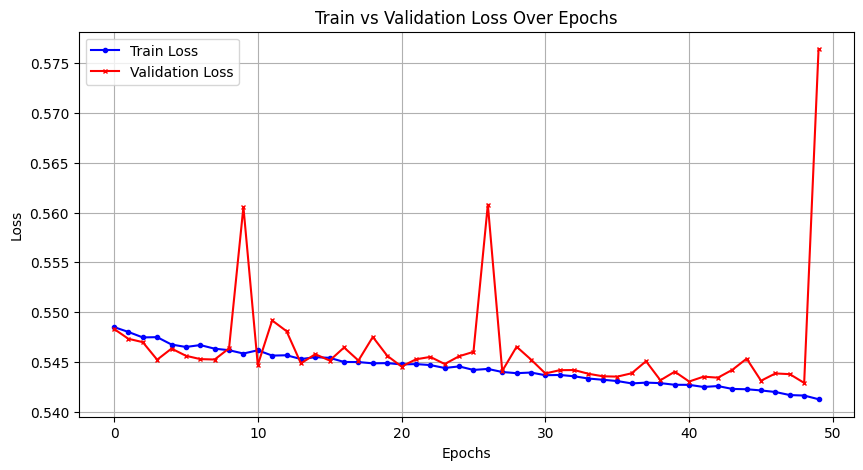

In [13]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import torch

num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', color='red', marker='x', markersize=3)
plt.title('Train vs Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_sk = X_train
X_test_sk = X_test

In [15]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_sk, y_train)
log_preds = log_model.predict(X_test_sk)
log_acc = accuracy_score(y_test, log_preds) * 100
print(f"LOG Test Accuracy: {log_acc:.2f}%")

LOG Test Accuracy: 61.80%


In [16]:
dnn_model = MLPClassifier(hidden_layer_sizes=(25,), random_state=42, max_iter=1000)
dnn_model.fit(X_train_sk, y_train)
dnn_preds = dnn_model.predict(X_test_sk)
dnn_acc = accuracy_score(y_test, dnn_preds) * 100
print(f"DNN Test Accuracy: {dnn_acc:.2f}%")

DNN Test Accuracy: 63.52%


In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sk, y_train)
rf_preds = rf_model.predict(X_test_sk)
rf_acc = accuracy_score(y_test, rf_preds) * 100
print(f"RAF Test Accuracy: {rf_acc:.2f}%")

RAF Test Accuracy: 94.51%
